In [1]:
import pandas as pd
import os
import glob
import re
import numpy as np
from datetime import datetime
from nemosis import static_table
from datetime import timedelta

raw_data_cache = '/Volumes/T7/NEMO-misc'

In [ ]:
import pandas as pd

parquet_path = "/Volumes/T7/melted-bids/bid-merged.parquet"
output_path = "/Volumes/T7/melted-bids/bid-merged-nonzero.parquet"

# 1) Read the Parquet file
df = pd.read_parquet(parquet_path)

# 2) Convert BIDVOLUME from object -> numeric
#    (this handles strings like "0", "310", etc.)
df["BIDVOLUME"] = pd.to_numeric(df["BIDVOLUME"], errors="coerce")

# 3) Filter out rows where BIDVOLUME == 0 or is NaN
df_nonzero = df[df["BIDVOLUME"].notna() & (df["BIDVOLUME"] != 0)]

print(f"Original rows: {len(df)}, after removing zero-volume: {len(df_nonzero)}")

# 4) Save filtered DataFrame back to Parquet
df_nonzero.to_parquet(output_path, index=False)
print(f"Saved filtered dataset to {output_path}")

Original rows: 11276320, after removing zero-volume: 3865769
Saved filtered dataset to /Volumes/T7/melted-bids/bid-merged-nonzero.parquet


In [ ]:
# Define the file path
file_path = '/Volumes/T7/melted-bids/bid-merged-nonzero.parquet'

# Read the Parquet file into a DataFrame
df = pd.read_parquet(file_path)

# Convert BIDPRICE to numeric, coercing errors to NaN
df['BIDPRICE'] = pd.to_numeric(df['BIDPRICE'], errors='coerce')

# Display descriptive statistics for the numeric BIDPRICE column
print("BIDPRICE Description:")
print(df['BIDPRICE'].describe())

BIDPRICE Description:
count    3.865769e+06
mean     3.423583e+03
std      5.716573e+03
min      0.000000e+00
25%      5.360000e+00
50%      7.499000e+01
75%      5.000000e+03
max      1.750000e+04
Name: BIDPRICE, dtype: float64


In [4]:
df.tail()

,SETTLEMENTDATE,DUID,BIDTYPE,OFFERDATE_x,MAXAVAIL,ENABLEMENTMIN,ENABLEMENTMAX,LOWBREAKPOINT,HIGHBREAKPOINT,INTERVAL_DATETIME,...,BIDVOLUME,OFFERDATE_y,VERSIONNO,MINIMUMLOAD,T1,T2,T3,T4,BIDPRICE,APPLICABLEFROM
3865764,2024-11-11,WKIEWA1,RAISEREG,2024/10/27 01:05:03,0,0,0,0,0,2024-11-11 18:05:00,...,34,2024/10/27 01:05:03,1,None,None,None,None,None,17500.0,2024-11-11 04:05:00
3865765,2024-11-11,WKIEWA2,LOWERREG,2024/10/27 01:06:02,0,0,0,0,0,2024-11-11 18:05:00,...,34,2024/10/27 01:06:02,1,None,None,None,None,None,17500.0,2024-11-11 04:05:00
3865766,2024-11-11,WKIEWA2,RAISEREG,2024/10/27 01:06:02,0,0,0,0,0,2024-11-11 18:05:00,...,34,2024/10/27 01:06:02,1,None,None,None,None,None,17500.0,2024-11-11 04:05:00
3865767,2024-11-11,YWPS3,RAISEREG,2024/10/29 12:46:25,0,250,385,250,370,2024-11-11 18:05:00,...,5,2024/10/29 12:46:25,1,None,None,None,None,None,11990.0,2024-11-11 04:05:00
3865768,2024-11-11,YWPS4,RAISEREG,2024/10/29 14:47:24,0,250,385,250,370,2024-11-11 18:05:00,...,5,2024/10/29 14:47:24,1,None,None,None,None,None,11900.0,2024-11-11 04:05:00


In [ ]:
# # Join DUIDs with firm names and further info
# generator_info_df = static_table(table_name='Generators and Scheduled Loads', 
#                               raw_data_location=raw_data_cache,
#                               update_static_file=False)
# generator_info_df

INFO: Retrieving static table Generators and Scheduled Loads


,Participant,Station Name,Region,Dispatch Type,Category,Classification,Fuel Source - Primary,Fuel Source - Descriptor,Technology Type - Primary,Technology Type - Descriptor,Aggregation,DUID
0,South Australian Water Corporation,Adelaide Desalination Plant,SA1,Generating Unit,Market,Scheduled,Battery storage,Grid,Storage,Battery and Inverter,Y,ADPBA1G
1,South Australian Water Corporation,Adelaide Desalination Plant,SA1,Load,Market,Scheduled,Battery storage,Grid,Storage,Battery and Inverter,Y,ADPBA1L
2,South Australian Water Corporation,Adelaide Desalination Plant,SA1,Generating Unit,Market,Non-Scheduled,Hydro,Water,Renewable,Run of River,Y,ADPMH1
3,South Australian Water Corporation,Adelaide Desalination Plant,SA1,Generating Unit,Market,Semi-Scheduled,Solar,Solar,Renewable,Photovoltaic Tracking Flat panel,Y,ADPPV1
4,South Australian Water Corporation,Adelaide Desalination Plant,SA1,Generating Unit,Market,Non-Scheduled,Solar,Solar,Renewable,Photovoltaic Flat panel,Y,ADPPV2
...,...,...,...,...,...,...,...,...,...,...,...,...
527,Tailem Bend II Project Company Pty Ltd as trus...,Tailem Bend 2 Hybrid Renewable Power Station,SA1,Bidirectional Unit,Market,Scheduled,Battery storage,Grid,Storage,Battery and Inverter,Y,TB2B1
528,AGL Macquarie Pty Limited,Broken Hill Battery Energy Storage System,NSW1,Bidirectional Unit,Market,Scheduled,Battery storage,Grid,Storage,Battery and Inverter,Y,BHB1
529,AGL SA Generation Pty Limited,Torrens Island BESS,SA1,Bidirectional Unit,Market,Scheduled,Battery storage,Grid,Storage,Battery and Inverter,Y,TIB1
530,Capital Battery Pty Ltd as Trustee for Capital...,Capital Battery,NSW1,Load,Market,Scheduled,Battery storage,Grid,Storage,Battery and Inverter,Y,CAPBES1


In [6]:
# Suppose you already have:
# 1) df_nonzero (filtered data) 
# 2) generator_info_df (the DataFrame with Station Name, Company, Region, etc.)

# Merge df_nonzero with generator_info_df on 'DUID'
enriched_df_nonzero = pd.merge(
    df,             # left DataFrame
    generator_info_df, 
    on='DUID',       # column common to both DataFrames
    how='left'       # or 'inner' if you only want matching DUIDs
)

# Now enriched_df_nonzero has extra columns from generator_info_df
print(enriched_df_nonzero.head())

  SETTLEMENTDATE      DUID   BIDTYPE          OFFERDATE_x MAXAVAIL  \
0     2009-07-01  BELLBAY1  LOWERREG  2005/04/21 14:31:20        0   
1     2009-07-01  BELLBAY1  RAISEREG  2005/04/21 14:31:20        0   
2     2009-07-01  BELLBAY2  LOWERREG  2005/04/21 14:31:20        0   
3     2009-07-01  BELLBAY2  RAISEREG  2005/04/21 14:31:20        0   
4     2009-07-01      BW01  LOWERREG  2009/07/01 09:11:49      100   

  ENABLEMENTMIN ENABLEMENTMAX LOWBREAKPOINT HIGHBREAKPOINT  \
0            36           120            49            120   
1            36           115            36            115   
2            36           120            49            120   
3            36           115            36            115   
4           300           690           400            690   

    INTERVAL_DATETIME  ...           Station Name_y Region_y  Dispatch Type_y  \
0 2009-07-01 18:05:00  ...                      NaN      NaN              NaN   
1 2009-07-01 18:05:00  ...                  

In [10]:
df_sa = df[df["Region"] == "SA1"].copy()
pd.set_option('display.max_columns', None)  # Temporarily allow unlimited columns
print(df_sa.head())                         # Now shows all columns in df_sa

   SETTLEMENTDATE    DUID   BIDTYPE          OFFERDATE_x MAXAVAIL  \
80     2009-07-01  TORRB1  LOWERREG  2009/06/30 11:24:02       25   
81     2009-07-01  TORRB1  RAISEREG  2009/06/30 11:24:02       40   
82     2009-07-01  TORRB2  LOWERREG  2009/06/30 11:24:02       25   
83     2009-07-01  TORRB3  LOWERREG  2009/06/30 11:24:02       25   
84     2009-07-01  TORRB3  RAISEREG  2009/06/30 11:24:02       40   

   ENABLEMENTMIN ENABLEMENTMAX LOWBREAKPOINT HIGHBREAKPOINT  \
80            40           205            65            180   
81            40           205            80            165   
82            40           205            65            180   
83            40           205            65            180   
84            40           205            80            165   

     INTERVAL_DATETIME                    Participant  \
80 2009-07-01 18:05:00  AGL SA Generation Pty Limited   
81 2009-07-01 18:05:00  AGL SA Generation Pty Limited   
82 2009-07-01 18:05:00  AGL SA Gene

In [16]:
# Filter df_sa to get only rows where Station Name contains "Hornsdale"
df_hornsdale = df_sa[
    df_sa["DUID"].str.contains("HPR1", case=False, na=False)
].copy()

print("Rows containing 'Hornsdale' in Station Name:")
print(df_hornsdale.head())

Rows containing 'Hornsdale' in Station Name:
                DUID   BIDTYPE          OFFERDATE_x MAXAVAIL ENABLEMENTMIN  \
SETTLEMENTDATE                                                               
2024-09-12      HPR1  RAISEREG  2024/09/10 11:08:43        0          -120   
2024-09-12      HPR1  LOWERREG  2024/09/10 11:08:43        0          -120   
2024-09-12      HPR1  LOWERREG  2024/09/10 11:08:43        0          -120   
2024-09-12      HPR1  LOWERREG  2024/09/10 11:08:43        0          -120   
2024-09-12      HPR1  LOWERREG  2024/09/10 11:08:43        0          -120   

               ENABLEMENTMAX LOWBREAKPOINT HIGHBREAKPOINT   INTERVAL_DATETIME  \
SETTLEMENTDATE                                                                  
2024-09-12               150          -120            150 2024-09-12 18:05:00   
2024-09-12               150          -120            150 2024-09-12 18:05:00   
2024-09-12               150          -120            150 2024-09-12 18:05:00   
202

In [13]:
df_hornsdale.sort_values(by="SETTLEMENTDATE", inplace=True)

print("Hornsdale rows, sorted by SETTLEMENTDATE:")
print(df_hornsdale.head())

Hornsdale rows, sorted by SETTLEMENTDATE:
        SETTLEMENTDATE   DUID   BIDTYPE          OFFERDATE_x MAXAVAIL  \
3416901     2017-12-01  HDWF2  LOWERREG  2017/12/01 15:17:15        0   
3416902     2017-12-01  HDWF2  RAISEREG  2017/12/01 15:17:15        0   
3417062     2017-12-02  HDWF2  LOWERREG  2017/12/01 15:17:15        0   
3417063     2017-12-02  HDWF2  RAISEREG  2017/12/01 15:17:15        0   
3417225     2017-12-03  HDWF2  LOWERREG  2017/12/01 15:17:15        0   

        ENABLEMENTMIN ENABLEMENTMAX LOWBREAKPOINT HIGHBREAKPOINT  \
3416901            15           102            15            102   
3416902            15           102            15            102   
3417062            15           102            15            102   
3417063            15           102            15            102   
3417225            15           102            15            102   

          INTERVAL_DATETIME    Participant           Station Name Region  \
3416901 2017-12-01 18:05:00  HWF 2

In [12]:
df_hornsdale.describe()

,SETTLEMENTDATE,INTERVAL_DATETIME,BIDBAND,BIDVOLUME,BIDPRICE,APPLICABLEFROM
count,21300,21300,21300.000000,21300.000000,21300.000000,21300
mean,2021-11-30 15:03:24.845070336,2021-12-01 09:08:24.845070848,3.429531,15.758685,1111.295414,2021-11-30 19:08:24.845070592
min,2017-12-01 00:00:00,2017-12-01 18:05:00,1.000000,1.000000,0.000000,2017-12-01 04:05:00
25%,2020-03-30 00:00:00,2020-03-30 18:05:00,1.000000,1.000000,0.000000,2020-03-30 04:05:00
50%,2021-12-19 00:00:00,2021-12-19 18:05:00,1.000000,19.000000,0.000000,2021-12-19 04:05:00
75%,2023-08-03 00:00:00,2023-08-03 18:05:00,7.000000,20.000000,256.000000,2023-08-03 04:05:00
max,2024-11-11 00:00:00,2024-11-11 18:05:00,10.000000,270.000000,17500.000000,2024-11-11 04:05:00
std,NaN,NaN,3.262476,20.731529,3703.984269,NaN


/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_20808/3182895007.py:38: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_20808/3182895007.py:38: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_20808/3182895007.py:38: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_20808/3182895007.py:38: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


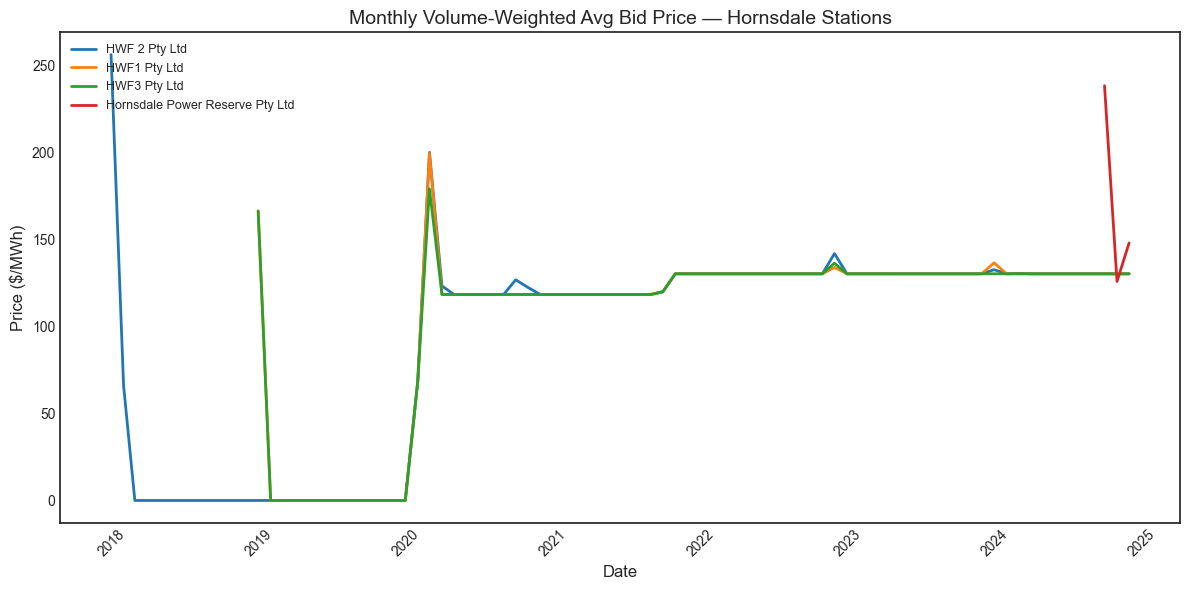

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

def volume_weighted_price(subdf):
    """Compute the volume-weighted average price for a subset of data."""
    total_volume = subdf["BIDVOLUME"].sum()
    if total_volume == 0:
        return None
    return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / total_volume

# Assume df_hornsdale is already sorted by SETTLEMENTDATE and has SETTLEMENTDATE as a DateTimeIndex:
# If not, you can do:
df_hornsdale.sort_values(by="SETTLEMENTDATE", inplace=True)
df_hornsdale["SETTLEMENTDATE"] = pd.to_datetime(df_hornsdale["SETTLEMENTDATE"])
df_hornsdale.set_index("SETTLEMENTDATE", inplace=True)

# Identify participants just in df_hornsdale
participants_hornsdale = df_hornsdale["Participant"].unique()

# Create the plot
plt.style.use("seaborn-v0_8-white")
fig, ax = plt.subplots(figsize=(12, 6))

# Use matplotlib's default color cycle
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for idx, participant in enumerate(participants_hornsdale):
    # Filter for this participant and remove bids above $1,000/MWh
    participant_df = df_hornsdale[df_hornsdale["Participant"] == participant].copy()
    participant_df = participant_df[participant_df["BIDPRICE"] <= 1000]
    
    if participant_df.empty:
        continue
    
    # Resample monthly and compute the volume-weighted average bid price
    monthly_weighted = (
        participant_df
        .resample("M")
        .apply(volume_weighted_price)
        .rename("WEIGHTED_PRICE")
    ).dropna()
    
    if monthly_weighted.empty:
        continue
    
    color = colors[idx % len(colors)]
    
    ax.plot(
        monthly_weighted.index,
        monthly_weighted,
        linestyle="-",
        linewidth=2,
        color=color,
        label=participant
    )

ax.set_title("Monthly Volume-Weighted Avg Bid Price — Hornsdale Stations", fontsize=14)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Price ($/MWh)", fontsize=12)
ax.legend(fontsize=9, loc='upper left', ncol=1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
print(df.columns.tolist())

['SETTLEMENTDATE', 'DUID', 'BIDTYPE', 'OFFERDATE_x', 'MAXAVAIL', 'ENABLEMENTMIN', 'ENABLEMENTMAX', 'LOWBREAKPOINT', 'HIGHBREAKPOINT', 'INTERVAL_DATETIME', 'Participant', 'Station Name', 'Region', 'Dispatch Type', 'Category', 'Classification', 'Fuel Source - Primary', 'Fuel Source - Descriptor', 'Technology Type - Primary', 'Technology Type - Descriptor', 'Aggregation', 'BIDBAND', 'BIDVOLUME', 'OFFERDATE_y', 'VERSIONNO', 'MINIMUMLOAD', 'T1', 'T2', 'T3', 'T4', 'BIDPRICE', 'APPLICABLEFROM']


/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_20808/3075642212.py:37: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_20808/3075642212.py:37: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_20808/3075642212.py:37: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_20808/3075642212.py:37: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_20808/3075642212.py:37: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/

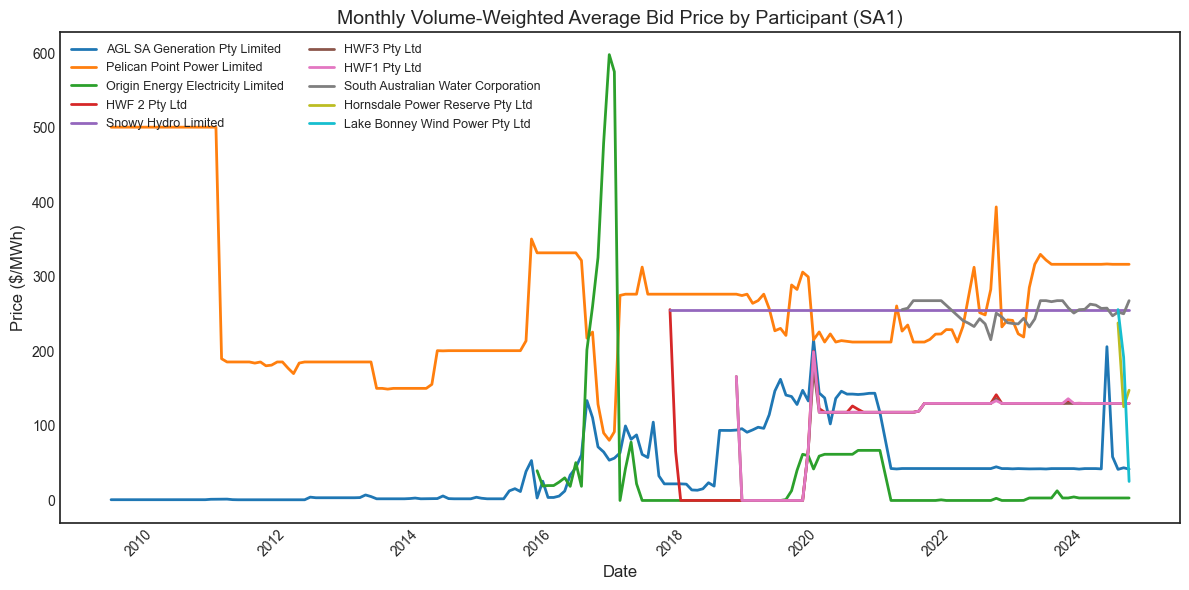

In [14]:
def volume_weighted_price(subdf):
    """Compute the volume-weighted average price for a subset of data."""
    total_volume = subdf["BIDVOLUME"].sum()
    if total_volume == 0:
        return None
    return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / total_volume



# Ensure we have a DateTime index for resampling
# Adjust the column name if needed (e.g. "SETTLEMENTDATE")
df_sa.sort_values(by="SETTLEMENTDATE", inplace=True)
df_sa["SETTLEMENTDATE"] = pd.to_datetime(df_sa["SETTLEMENTDATE"])
df_sa.set_index("SETTLEMENTDATE", inplace=True)

# 2) Identify *all* participants in SA
participants_in_sa = df_sa["Participant"].unique()

# 3) Create a plot
plt.style.use("seaborn-v0_8-white")
fig, ax = plt.subplots(figsize=(12, 6))

# Use matplotlib's default color cycle
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for idx, participant in enumerate(participants_in_sa):
    # Filter for this participant and remove bids above $1,000/MWh
    participant_df = df_sa[df_sa["Participant"] == participant].copy()
    participant_df = participant_df[participant_df["BIDPRICE"] <= 1000]
    
    if participant_df.empty:
        continue
    
    # Resample monthly and compute the volume-weighted average bid price
    monthly_weighted = (
        participant_df
        .resample("M")
        .apply(volume_weighted_price)
        .rename("WEIGHTED_PRICE")
    ).dropna()
    
    if monthly_weighted.empty:
        continue
    
    # Pick a color from the cycle
    color = colors[idx % len(colors)]
    
    ax.plot(
        monthly_weighted.index,
        monthly_weighted,
        linestyle="-",
        linewidth=2,
        color=color,
        label=participant
    )

# 4) Customize the plot
ax.set_title("Monthly Volume-Weighted Average Bid Price by Participant (SA1)", fontsize=14)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Price ($/MWh)", fontsize=12)
ax.legend(fontsize=9, loc='upper left', ncol=2)  # ncol=2 to make legend narrower
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Example list of top participants you found ---
top_participants = [
    "AGL Macquarie Pty Limited",
    "CS Energy Limited",
    "Origin Energy Electricity Limited",
    "AGL Loy Yang Marketing Pty Ltd",
    "Stanwell Corporation Limited",
    "AGL SA Generation Pty Limited",
    "Delta Electricity",
    # ... add more if needed
]

def volume_weighted_price(subdf):
    # Avoid division by zero if total volume is zero
    if subdf["BIDVOLUME"].sum() == 0:
        return None
    return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()

# Create one figure for all participants
plt.style.use("seaborn-v0_8-white")
fig, ax = plt.subplots(figsize=(12, 6))

# Use matplotlib's default color cycle
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for idx, participant in enumerate(top_participants):
    # Filter for a single participant and remove bids above $5,000/MWh
    participant_df = df[df["Participant"] == participant].copy()
    participant_df = participant_df[participant_df["BIDPRICE"] <= 1000]
    
    if participant_df.empty:
        print(f"No valid data for {participant} after filtering; skipping.")
        continue
    
    # Resample monthly and compute the volume-weighted average bid price
    monthly_weighted = (
        participant_df
        .resample("M")
        .apply(volume_weighted_price)
        .rename("WEIGHTED_PRICE")
    )
    monthly_weighted = monthly_weighted.dropna()
    if monthly_weighted.empty:
        print(f"No valid monthly data for {participant} after resampling; skipping.")
        continue
    
    # Apply a one-month moving average (window=1, which returns the same monthly values)
    monthly_weighted_smoothed = monthly_weighted.rolling(window=1, center=True).mean()
    
    color = colors[idx % len(colors)]
    
    ax.plot(
        monthly_weighted_smoothed.index,
        monthly_weighted_smoothed,
        linestyle="-",
        linewidth=2,
        color=color,
        label=participant
    )

# Set the title and labels for the combined plot
ax.set_title("Monthly Volume-Weighted Average Bid Price by Firm\n(1-Month Moving Average)", fontsize=14)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Price ($/MWh)", fontsize=12)
ax.legend(fontsize=10, loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/637724955.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g["BIDPRICE"] * g["BIDVOLUME"]).sum() / g["BIDVOLUME"].sum())


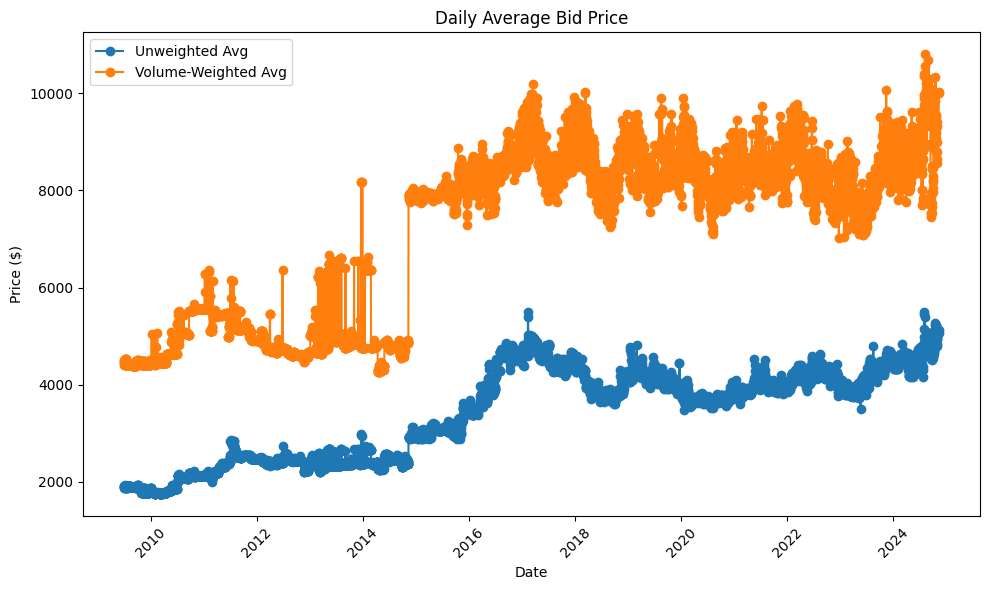

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Read your Parquet file (adjust the path as needed)
file_path = "/Volumes/T7/melted-bids/bid-merged-nonzero.parquet"
df = pd.read_parquet(file_path)

# 2) Ensure SETTLEMENTDATE is datetime
df["SETTLEMENTDATE"] = pd.to_datetime(df["SETTLEMENTDATE"])

# 3) Create a daily date column for grouping
df["DATE"] = df["SETTLEMENTDATE"].dt.date  # or .floor("D")

# 4) Convert BIDPRICE / BIDVOLUME to numeric (if not already)
df["BIDPRICE"] = pd.to_numeric(df["BIDPRICE"], errors="coerce")
df["BIDVOLUME"] = pd.to_numeric(df["BIDVOLUME"], errors="coerce")

# 5) Compute the unweighted daily average
daily_unweighted = (
    df.groupby("DATE")["BIDPRICE"]
      .mean()
      .reset_index(name="UNWEIGHTED_PRICE")
)

# 6) Compute the daily volume-weighted average price
#    Weighted average = sum(price*volume) / sum(volume) for each day
daily_weighted = (
    df.groupby("DATE")
      .apply(lambda g: (g["BIDPRICE"] * g["BIDVOLUME"]).sum() / g["BIDVOLUME"].sum())
      .reset_index(name="WEIGHTED_PRICE")
)

# 7) Merge these two DataFrames so we can plot both lines
merged_daily = pd.merge(daily_unweighted, daily_weighted, on="DATE", how="inner")

# 8) Plot the results
plt.figure(figsize=(10,6))

plt.plot(merged_daily["DATE"], merged_daily["UNWEIGHTED_PRICE"], 
         label="Unweighted Avg", marker="o")
plt.plot(merged_daily["DATE"], merged_daily["WEIGHTED_PRICE"], 
         label="Volume-Weighted Avg", marker="o")

plt.title("Daily Average Bid Price")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
import matplotlib.pyplot as plt
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/3721097423.py:24: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/3721097423.py:34: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/3721097423.py:31: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


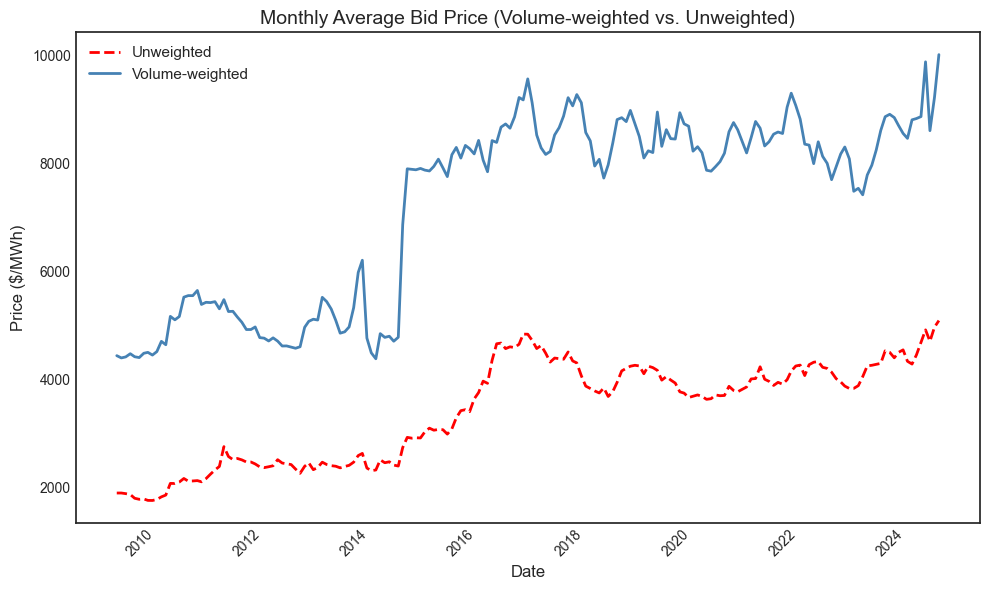

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Read your data
file_path = "/Volumes/T7/melted-bids/bid-merged-nonzero.parquet"
df = pd.read_parquet(file_path)

# 2) Convert to datetime if needed
df["SETTLEMENTDATE"] = pd.to_datetime(df["SETTLEMENTDATE"])

# 3) Convert BIDPRICE / BIDVOLUME to numeric
df["BIDPRICE"] = pd.to_numeric(df["BIDPRICE"], errors="coerce")
df["BIDVOLUME"] = pd.to_numeric(df["BIDVOLUME"], errors="coerce")

# ------------------------------------------------------------------
# AGGREGATE BY MONTH
# ------------------------------------------------------------------

df.set_index("SETTLEMENTDATE", inplace=True)

# Unweighted monthly average
monthly_unweighted = (
    df["BIDPRICE"]
    .resample("M")
    .mean()
    .rename("UNWEIGHTED_PRICE")
)

# Volume-weighted monthly average
def volume_weighted_price(subdf):
    return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()

monthly_weighted = (
    df.resample("M")
      .apply(volume_weighted_price)
      .rename("WEIGHTED_PRICE")
)

# Combine into a single DataFrame
monthly_df = pd.concat([monthly_unweighted, monthly_weighted], axis=1).dropna()

# ------------------------------------------------------------------
# PLOTTING
# ------------------------------------------------------------------

plt.style.use("seaborn-v0_8-white")  # or "seaborn-v0_8-whitegrid", etc.
fig, ax = plt.subplots(figsize=(10, 6))

# Plot unweighted
ax.plot(
    monthly_df.index,
    monthly_df["UNWEIGHTED_PRICE"],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Unweighted"
)

# Plot volume-weighted
ax.plot(
    monthly_df.index,
    monthly_df["WEIGHTED_PRICE"],
    color="steelblue",
    linestyle="-",
    linewidth=2,
    label="Volume-weighted"
)

ax.set_title("Monthly Average Bid Price (Volume-weighted vs. Unweighted)", fontsize=14)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Price ($/MWh)", fontsize=12)
ax.legend(fontsize=11)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/1126758465.py:27: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


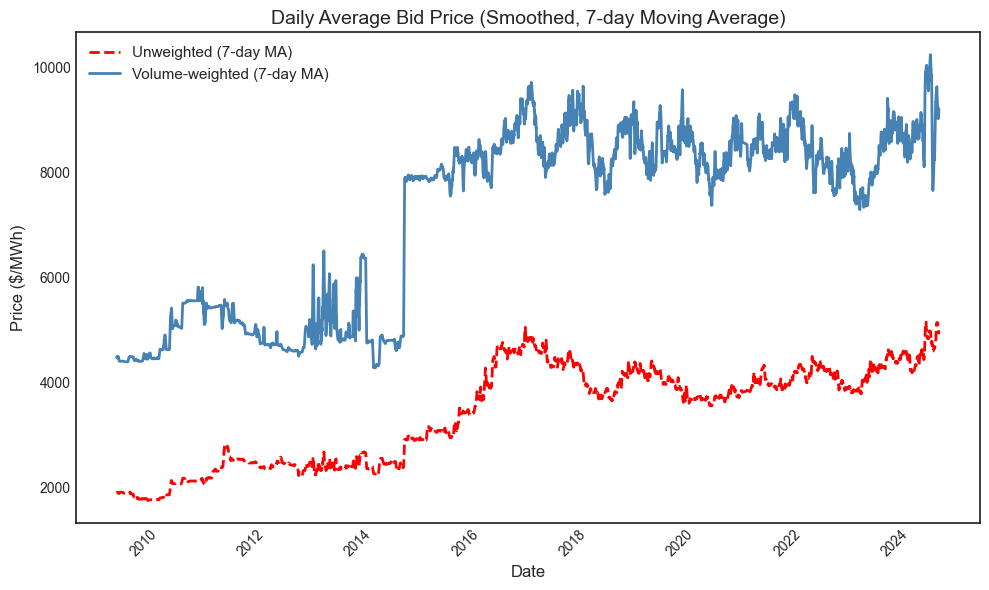

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) Read your data
file_path = "/Volumes/T7/melted-bids/bid-merged-nonzero.parquet"
df = pd.read_parquet(file_path)

# 2) Convert to datetime if needed
df["SETTLEMENTDATE"] = pd.to_datetime(df["SETTLEMENTDATE"])

# 3) Convert BIDPRICE / BIDVOLUME to numeric
df["BIDPRICE"] = pd.to_numeric(df["BIDPRICE"], errors="coerce")
df["BIDVOLUME"] = pd.to_numeric(df["BIDVOLUME"], errors="coerce")

# Set the datetime column as the index
df.set_index("SETTLEMENTDATE", inplace=True)

# ------------------------------------------------------------------
# AGGREGATE BY DAY
# ------------------------------------------------------------------

# Unweighted daily average
daily_unweighted = df["BIDPRICE"].resample("D").mean().rename("UNWEIGHTED_PRICE")

# Volume-weighted daily average
def volume_weighted_price(subdf):
    return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()

daily_weighted = df.resample("D").apply(volume_weighted_price).rename("WEIGHTED_PRICE")

# Combine into a single DataFrame and drop any days with missing values
daily_df = pd.concat([daily_unweighted, daily_weighted], axis=1).dropna()

# ------------------------------------------------------------------
# SMOOTHING
# ------------------------------------------------------------------
# Apply a 7-day moving average to smooth the daily fluctuations
window_size = 7  # Adjust window size as needed for smoothing
daily_df["UNWEIGHTED_PRICE_SMOOTH"] = daily_df["UNWEIGHTED_PRICE"].rolling(window=window_size, center=True).mean()
daily_df["WEIGHTED_PRICE_SMOOTH"] = daily_df["WEIGHTED_PRICE"].rolling(window=window_size, center=True).mean()

# ------------------------------------------------------------------
# PLOTTING
# ------------------------------------------------------------------
plt.style.use("seaborn-v0_8-white")
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the smoothed unweighted daily price
ax.plot(
    daily_df.index,
    daily_df["UNWEIGHTED_PRICE_SMOOTH"],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Unweighted (7-day MA)"
)

# Plot the smoothed volume-weighted daily price
ax.plot(
    daily_df.index,
    daily_df["WEIGHTED_PRICE_SMOOTH"],
    color="steelblue",
    linestyle="-",
    linewidth=2,
    label="Volume-weighted (7-day MA)"
)

ax.set_title("Daily Average Bid Price (Smoothed, 7-day Moving Average)", fontsize=14)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Price ($/MWh)", fontsize=12)
ax.legend(fontsize=11)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/566336903.py:24: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


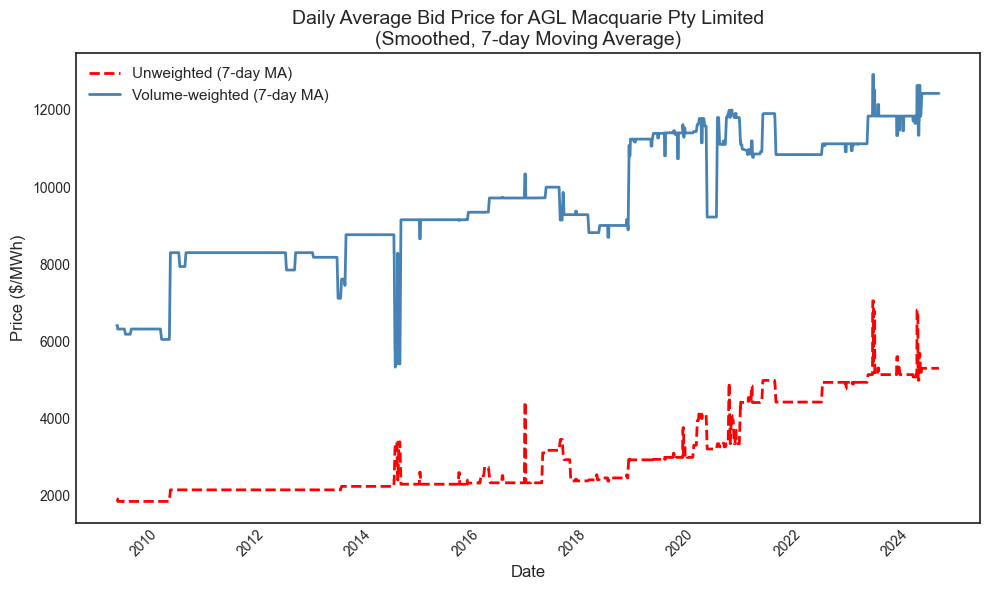

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/566336903.py:24: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


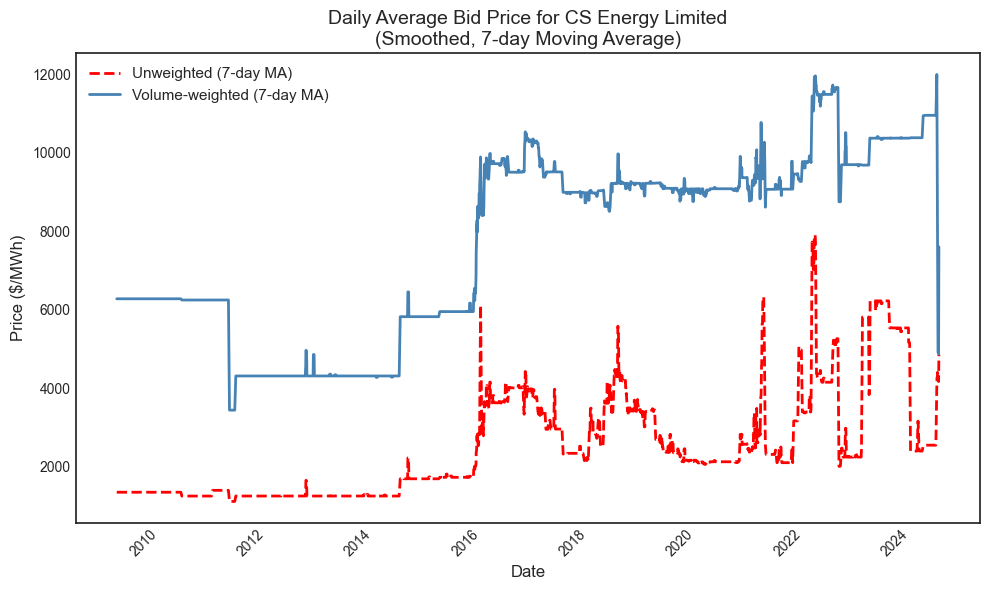

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/566336903.py:24: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


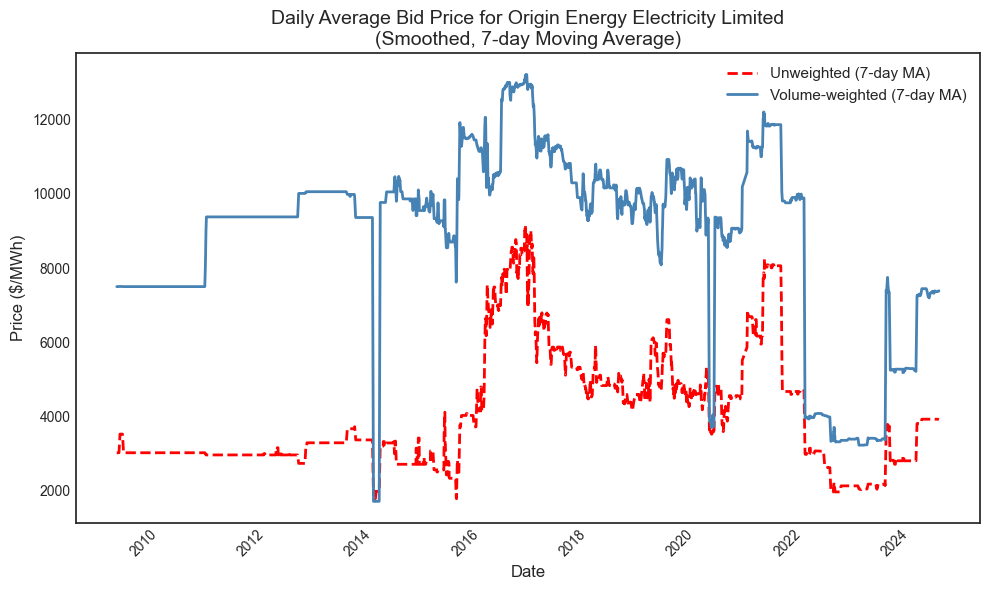

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/566336903.py:24: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


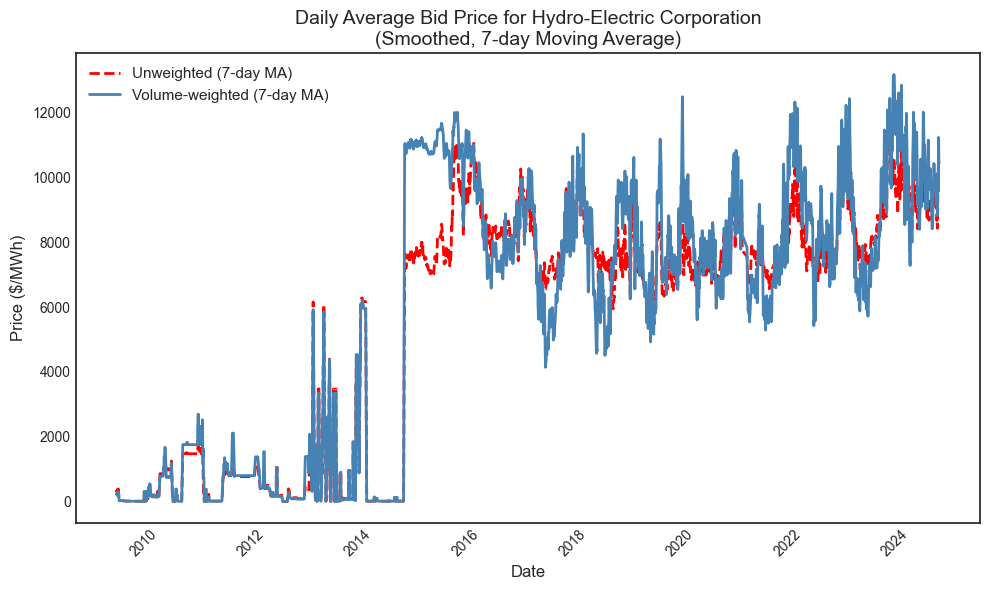

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/566336903.py:24: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


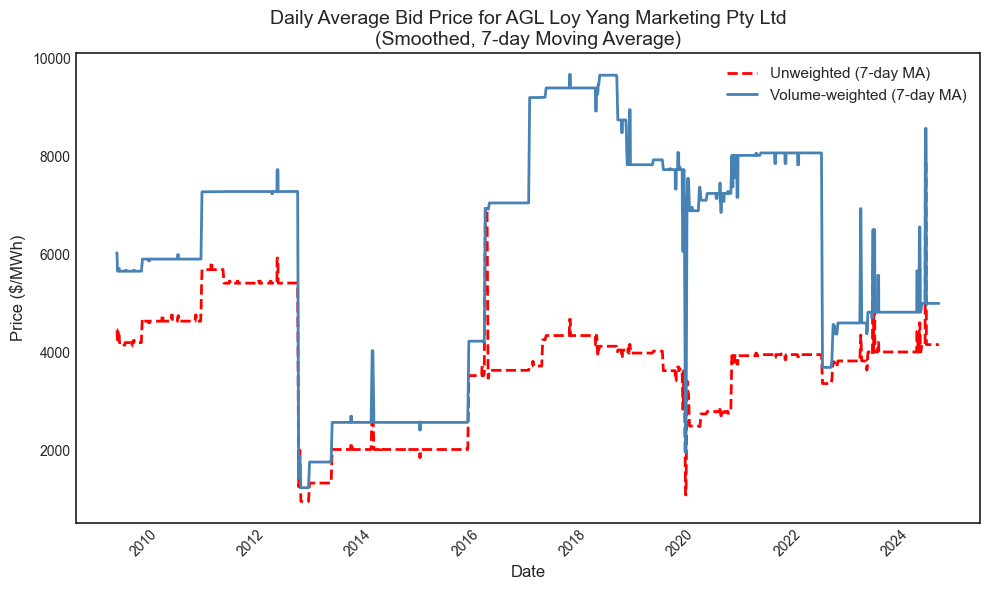

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/566336903.py:24: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


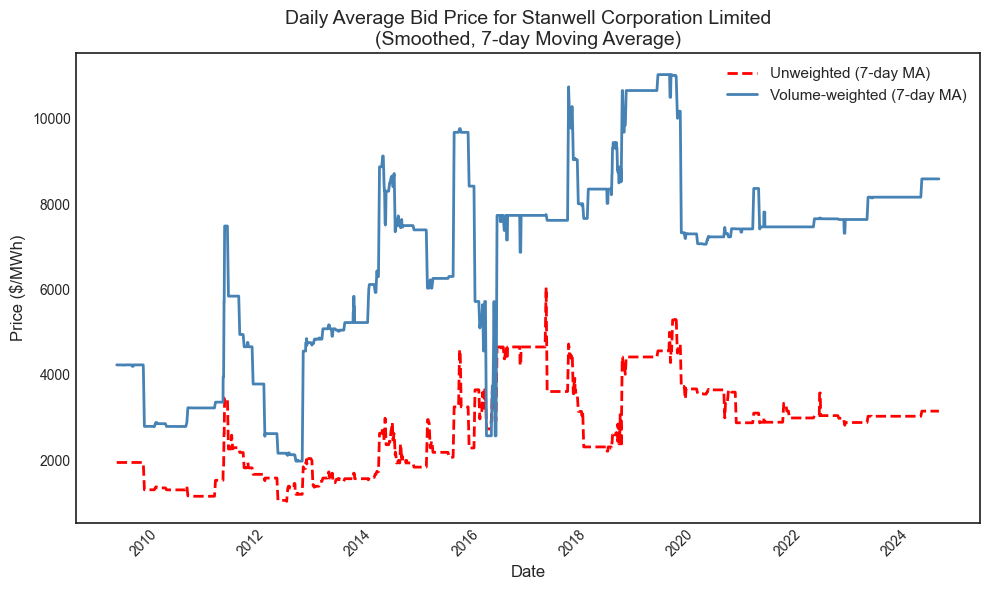

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/566336903.py:24: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


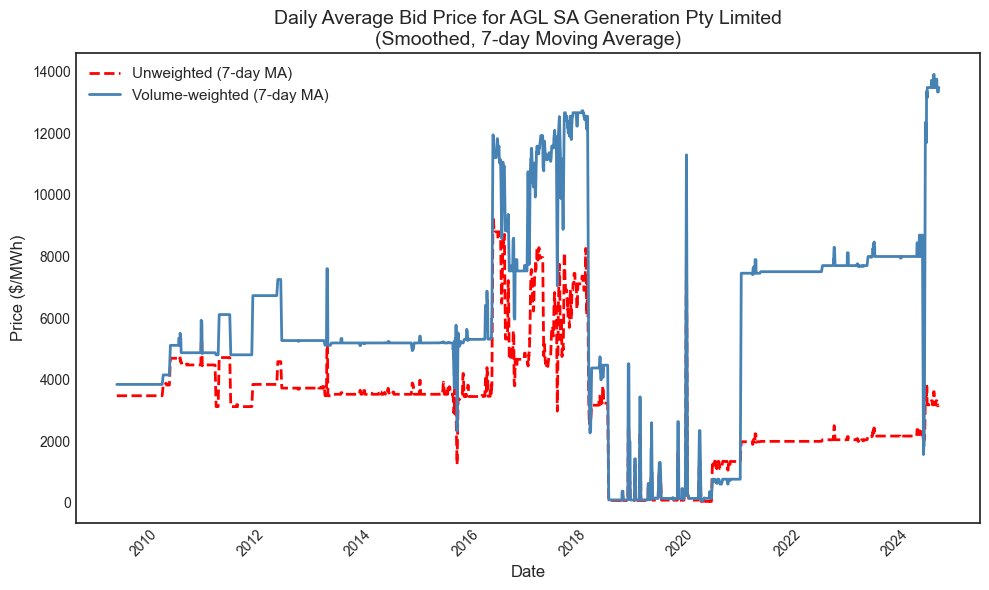

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/566336903.py:24: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


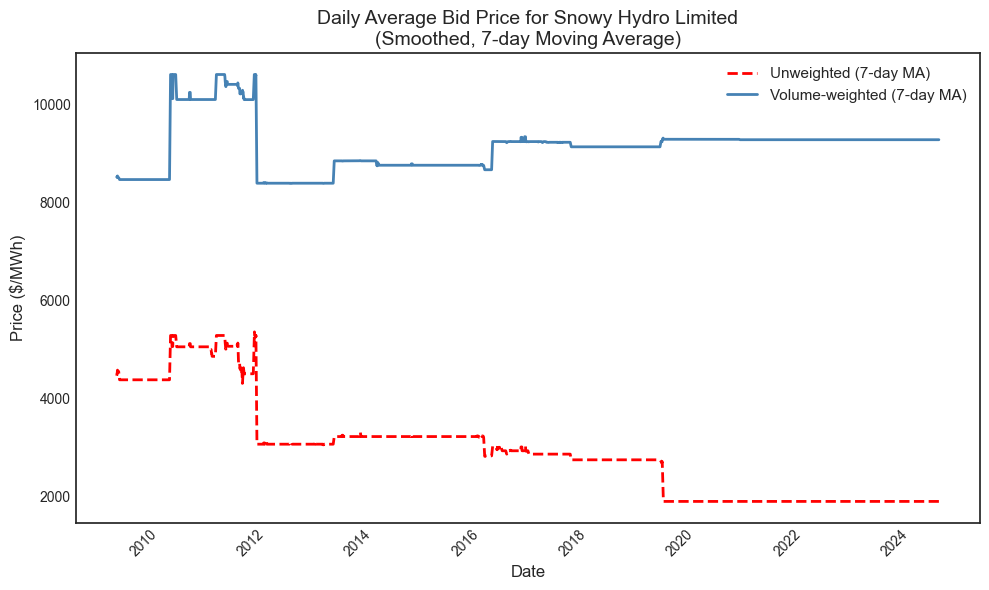

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/566336903.py:24: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


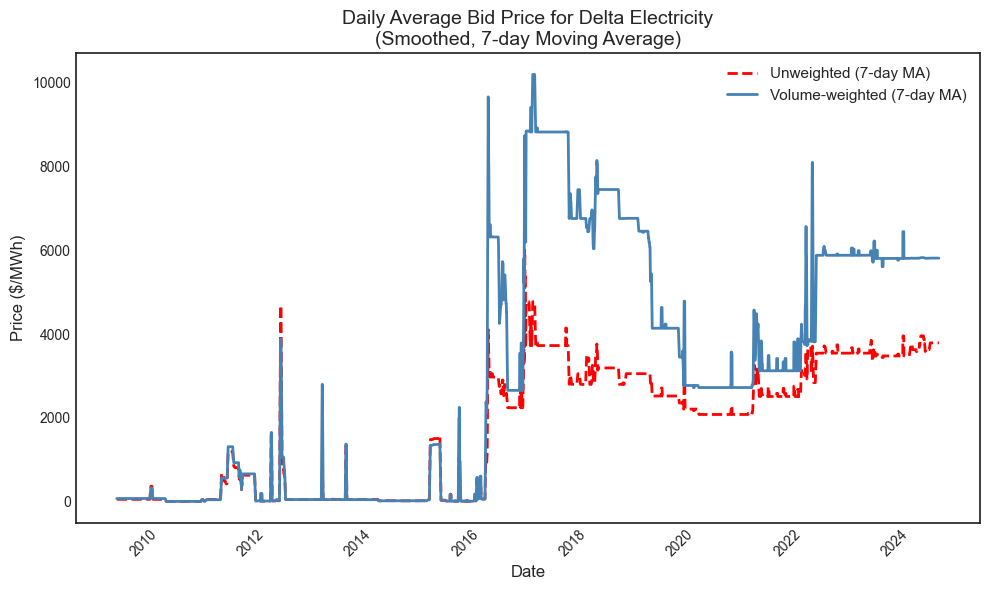

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Example list of top participants you found ---
top_participants = [
    "AGL Macquarie Pty Limited",
    "CS Energy Limited",
    "Origin Energy Electricity Limited",
    "Hydro-Electric Corporation",
    "AGL Loy Yang Marketing Pty Ltd",
    "Stanwell Corporation Limited",
    "AGL SA Generation Pty Limited",
    "Snowy Hydro Limited",
    "Delta Electricity",
    # ... add more if needed
]

# Make sure your DataFrame is already loaded in `df` and set up:
# df.set_index("SETTLEMENTDATE", inplace=True)
# df["BIDPRICE"] = pd.to_numeric(df["BIDPRICE"], errors="coerce")
# df["BIDVOLUME"] = pd.to_numeric(df["BIDVOLUME"], errors="coerce")

def volume_weighted_price(subdf):
    return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()

for participant in top_participants:
    # 1) Filter for a single participant
    participant_df = df[df["Participant"] == participant].copy()
    if participant_df.empty:
        print(f"No data for {participant}; skipping.")
        continue
    
    # 2) Resample daily: unweighted and volume-weighted
    daily_unweighted = (
        participant_df["BIDPRICE"]
        .resample("D")
        .mean()
        .rename("UNWEIGHTED_PRICE")
    )
    daily_weighted = (
        participant_df
        .resample("D")
        .apply(volume_weighted_price)
        .rename("WEIGHTED_PRICE")
    )
    
    # 3) Combine and optionally drop days with missing values
    daily_df = pd.concat([daily_unweighted, daily_weighted], axis=1).dropna()
    if daily_df.empty:
        print(f"No valid daily data for {participant}; skipping.")
        continue
    
    # 4) Smooth with a 7-day moving average
    window_size = 7
    daily_df["UNWEIGHTED_PRICE_SMOOTH"] = (
        daily_df["UNWEIGHTED_PRICE"].rolling(window_size, center=True).mean()
    )
    daily_df["WEIGHTED_PRICE_SMOOTH"] = (
        daily_df["WEIGHTED_PRICE"].rolling(window_size, center=True).mean()
    )
    
    # 5) Plot each participant on its own figure
    plt.style.use("seaborn-v0_8-white")
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(
        daily_df.index,
        daily_df["UNWEIGHTED_PRICE_SMOOTH"],
        color="red",
        linestyle="--",
        linewidth=2,
        label="Unweighted (7-day MA)"
    )
    ax.plot(
        daily_df.index,
        daily_df["WEIGHTED_PRICE_SMOOTH"],
        color="steelblue",
        linestyle="-",
        linewidth=2,
        label="Volume-weighted (7-day MA)"
    )
    
    ax.set_title(
        f"Daily Average Bid Price for {participant}\n(Smoothed, 7-day Moving Average)",
        fontsize=14
    )
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Price ($/MWh)", fontsize=12)
    ax.legend(fontsize=11)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/1134454253.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


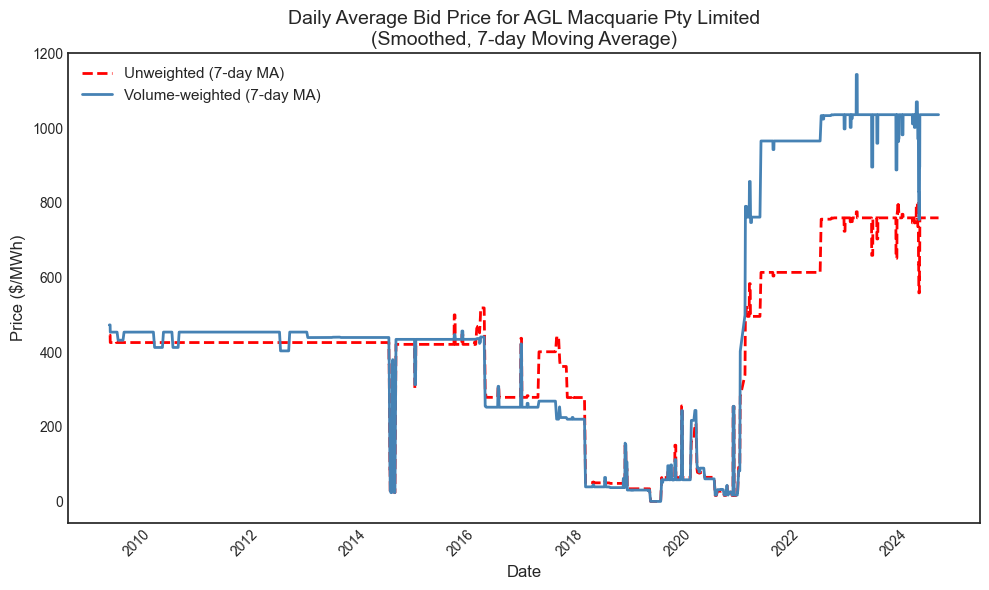

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/1134454253.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


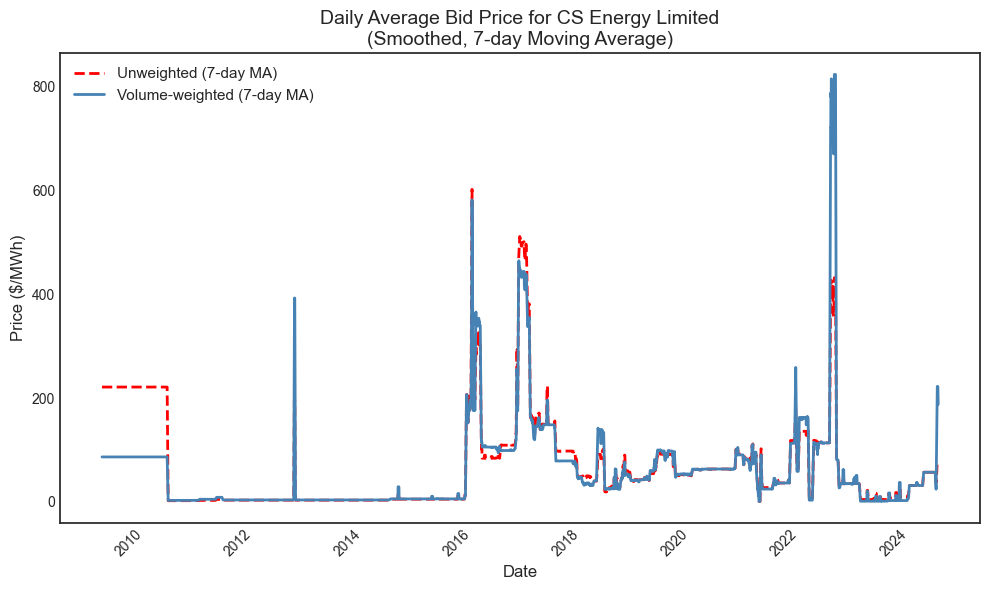

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/1134454253.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


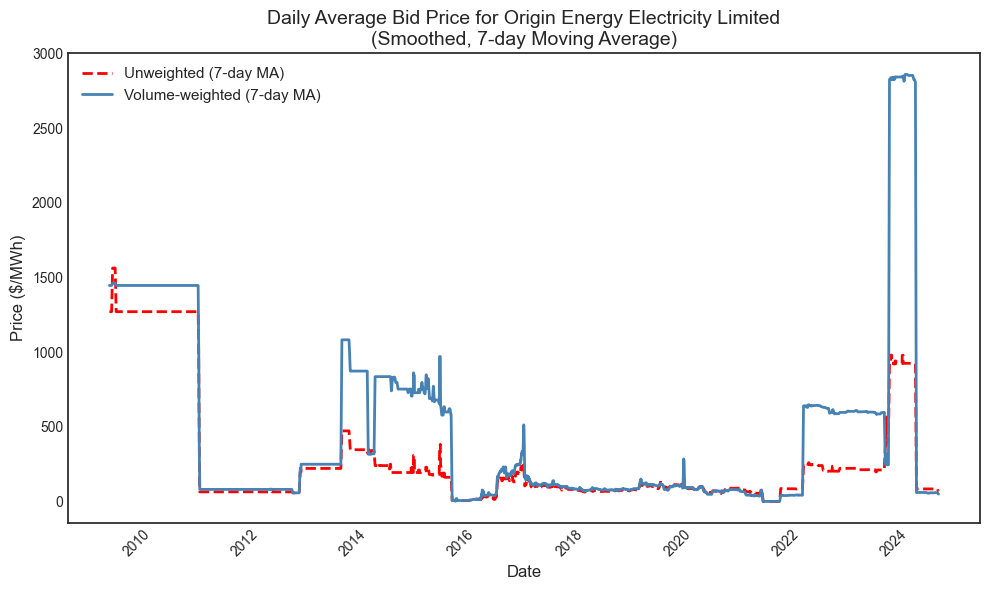

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/1134454253.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


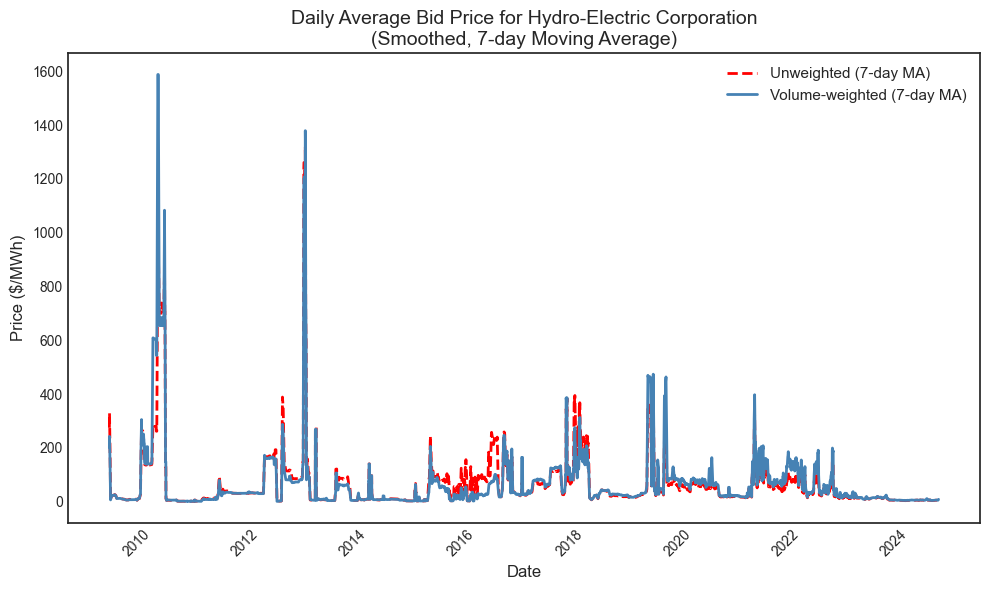

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/1134454253.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


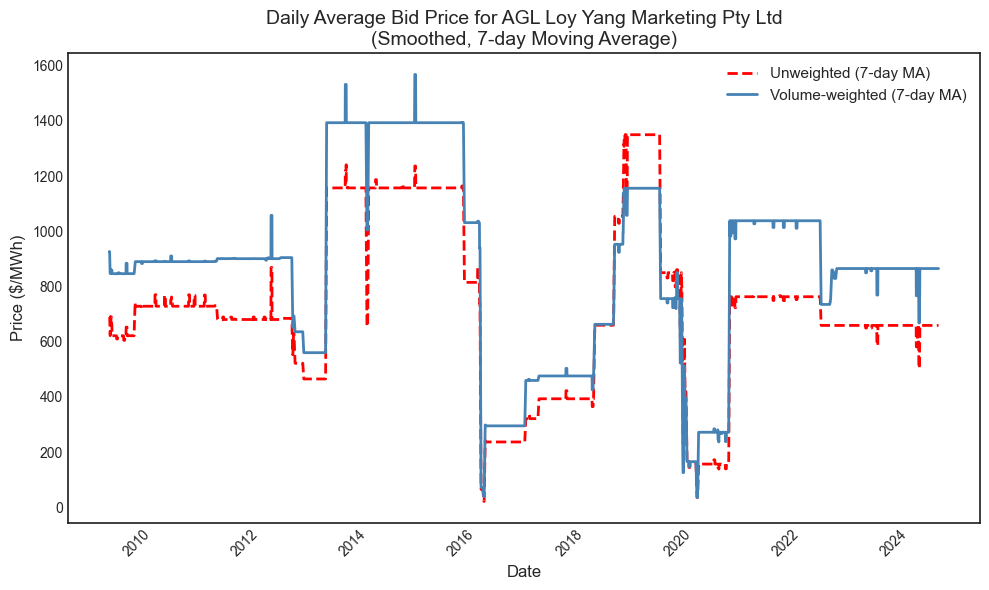

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/1134454253.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


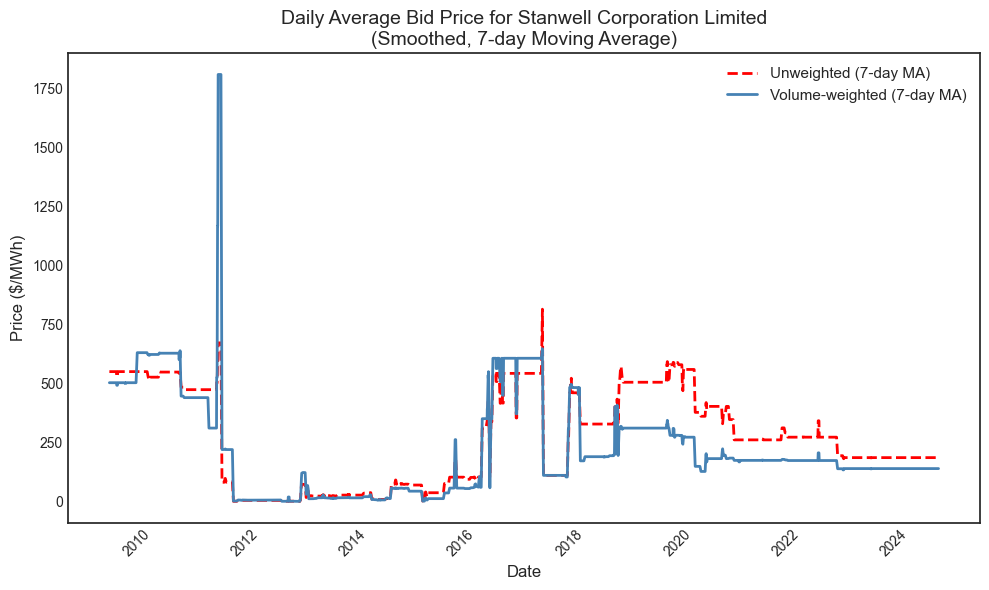

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/1134454253.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


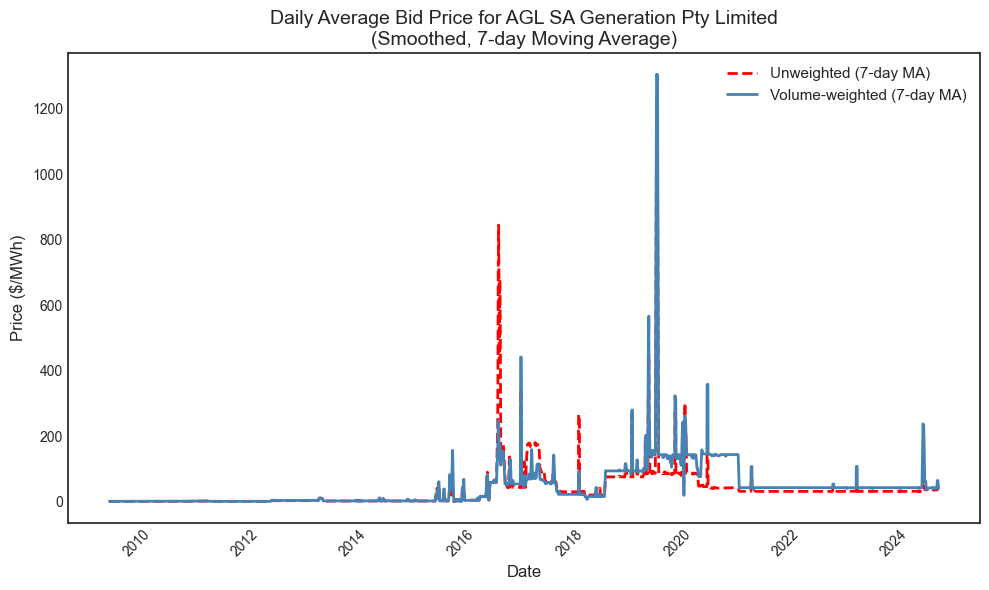

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/1134454253.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


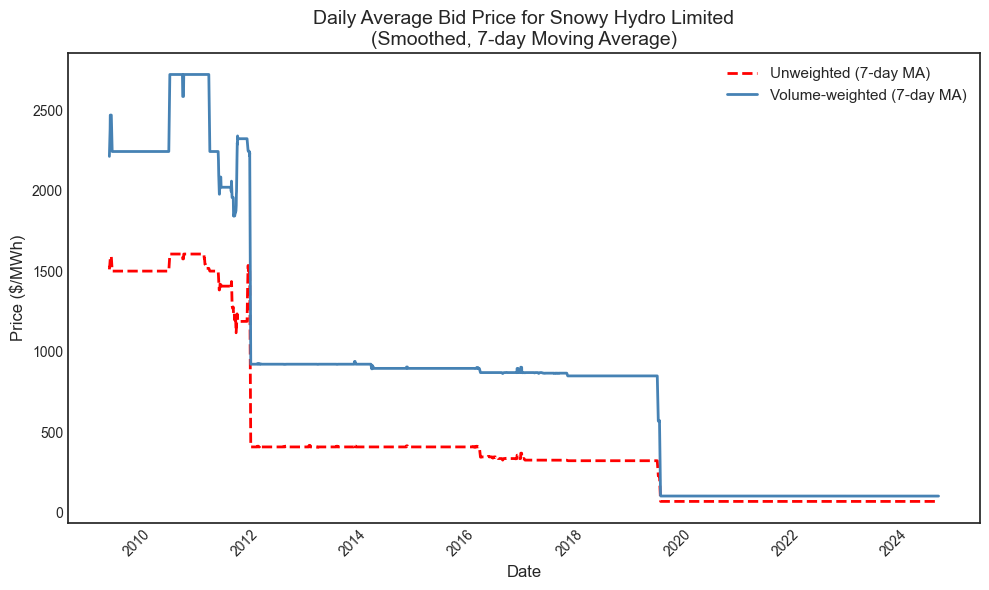

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/1134454253.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


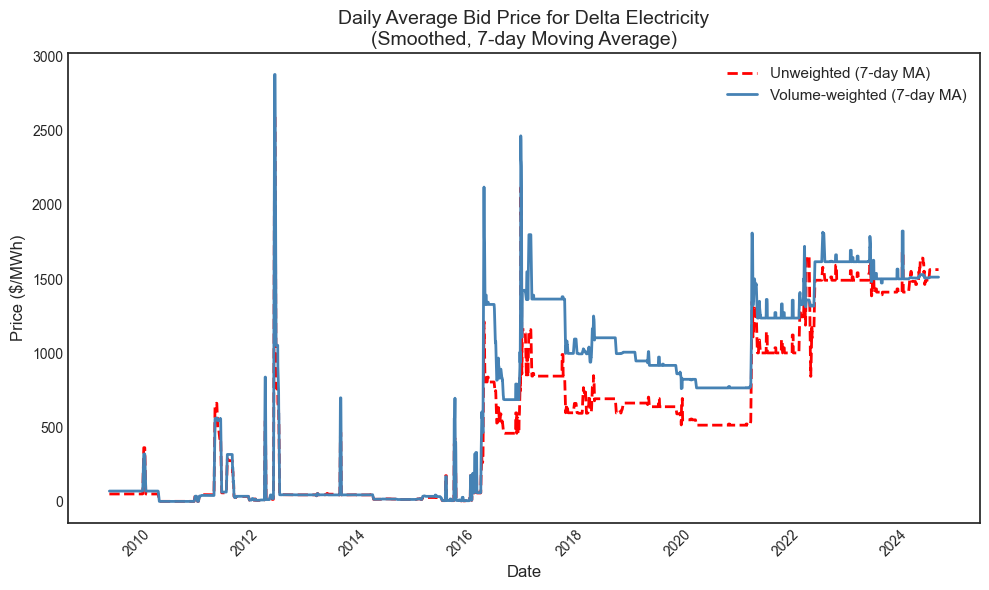

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Example list of top participants you found ---
top_participants = [
    "AGL Macquarie Pty Limited",
    "CS Energy Limited",
    "Origin Energy Electricity Limited",
    "Hydro-Electric Corporation",
    "AGL Loy Yang Marketing Pty Ltd",
    "Stanwell Corporation Limited",
    "AGL SA Generation Pty Limited",
    "Snowy Hydro Limited",
    "Delta Electricity",
    # ... add more if needed
]

def volume_weighted_price(subdf):
    return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()

for participant in top_participants:
    # 1) Filter for a single participant and remove bids above $5,000/MWh
    participant_df = df[df["Participant"] == participant].copy()
    participant_df = participant_df[participant_df["BIDPRICE"] <= 5000]
    
    if participant_df.empty:
        print(f"No valid data for {participant} after filtering; skipping.")
        continue
    
    # 2) Resample daily: unweighted and volume-weighted
    daily_unweighted = (
        participant_df["BIDPRICE"]
        .resample("D")
        .mean()
        .rename("UNWEIGHTED_PRICE")
    )
    daily_weighted = (
        participant_df
        .resample("D")
        .apply(volume_weighted_price)
        .rename("WEIGHTED_PRICE")
    )
    
    # 3) Combine and drop days with missing values
    daily_df = pd.concat([daily_unweighted, daily_weighted], axis=1).dropna()
    if daily_df.empty:
        print(f"No valid daily data for {participant} after resampling; skipping.")
        continue
    
    # 4) Smooth with a 7-day moving average
    window_size = 7
    daily_df["UNWEIGHTED_PRICE_SMOOTH"] = (
        daily_df["UNWEIGHTED_PRICE"].rolling(window_size, center=True).mean()
    )
    daily_df["WEIGHTED_PRICE_SMOOTH"] = (
        daily_df["WEIGHTED_PRICE"].rolling(window_size, center=True).mean()
    )
    
    # 5) Plot each participant on its own figure
    plt.style.use("seaborn-v0_8-white")
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(
        daily_df.index,
        daily_df["UNWEIGHTED_PRICE_SMOOTH"],
        color="red",
        linestyle="--",
        linewidth=2,
        label="Unweighted (7-day MA)"
    )
    ax.plot(
        daily_df.index,
        daily_df["WEIGHTED_PRICE_SMOOTH"],
        color="steelblue",
        linestyle="-",
        linewidth=2,
        label="Volume-weighted (7-day MA)"
    )
    
    ax.set_title(
        f"Daily Average Bid Price for {participant}\n(Smoothed, 7-day Moving Average)",
        fontsize=14
    )
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Price ($/MWh)", fontsize=12)
    ax.legend(fontsize=11)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:33: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


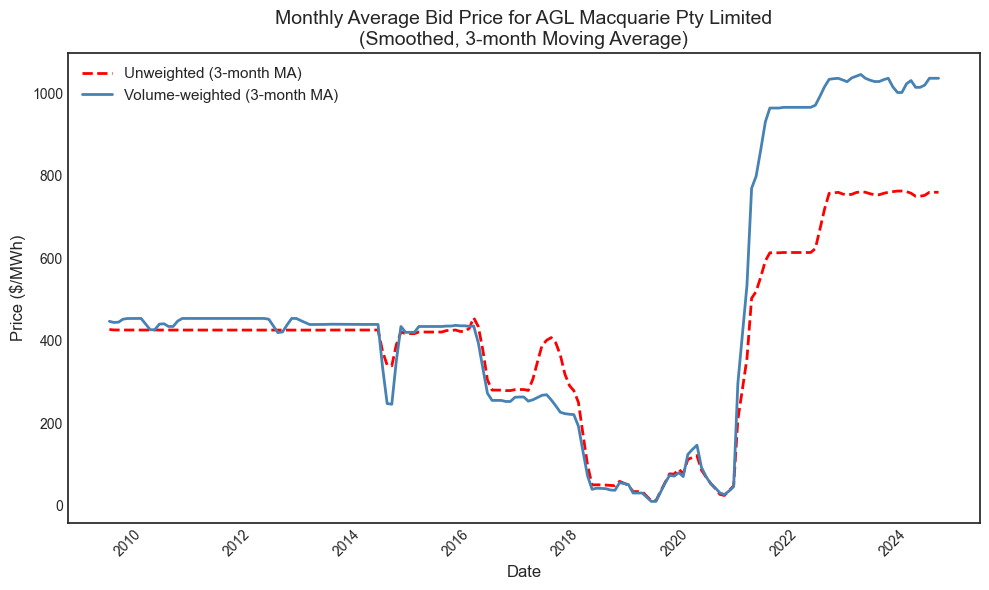

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:33: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


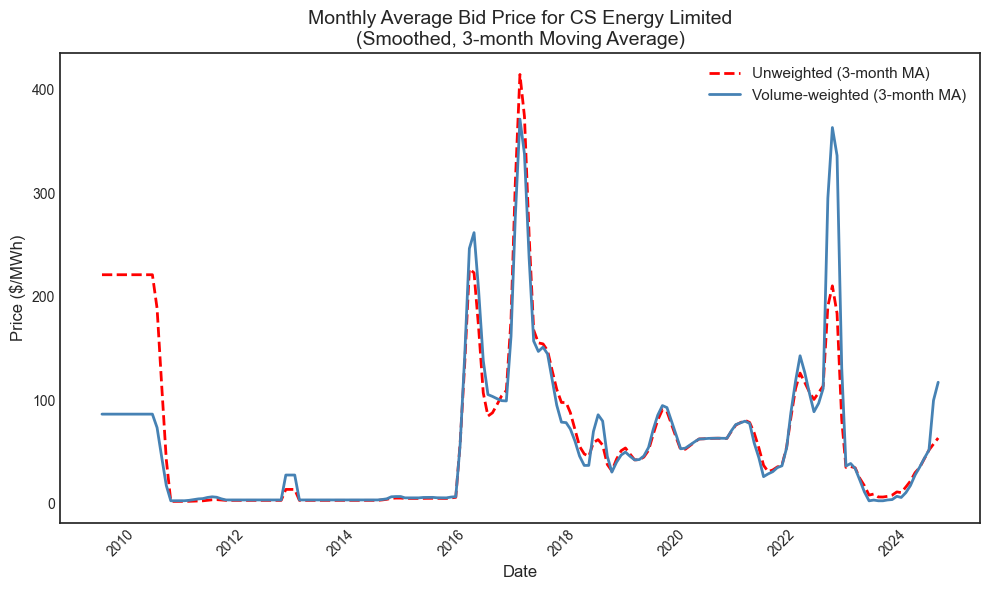

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:33: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


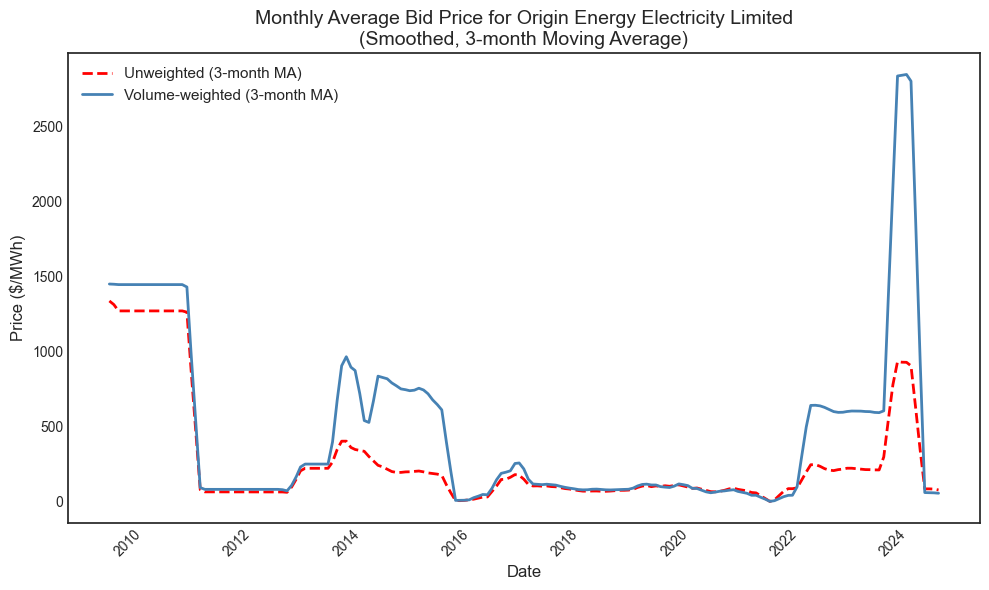

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:33: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


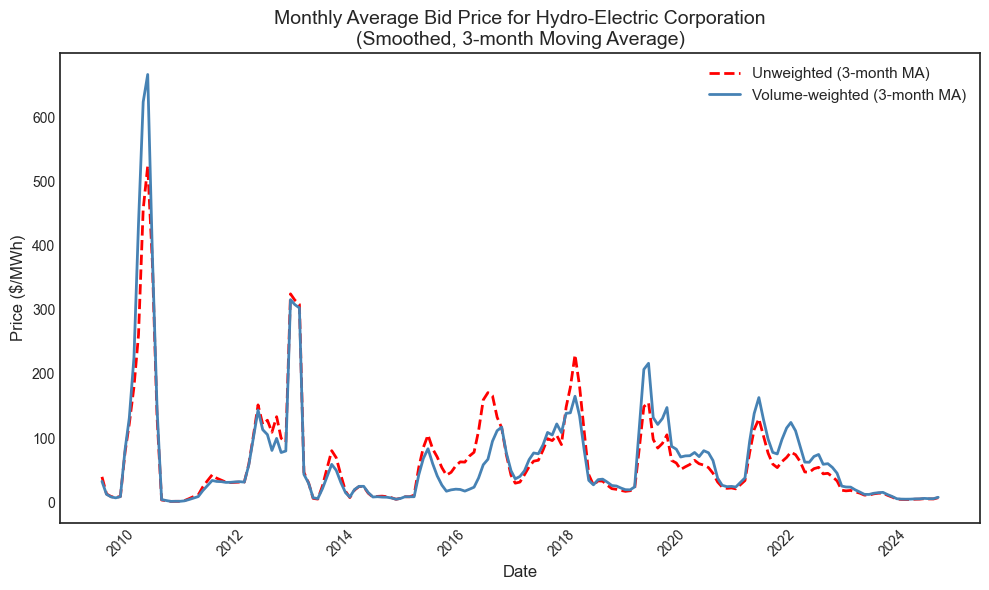

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:33: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


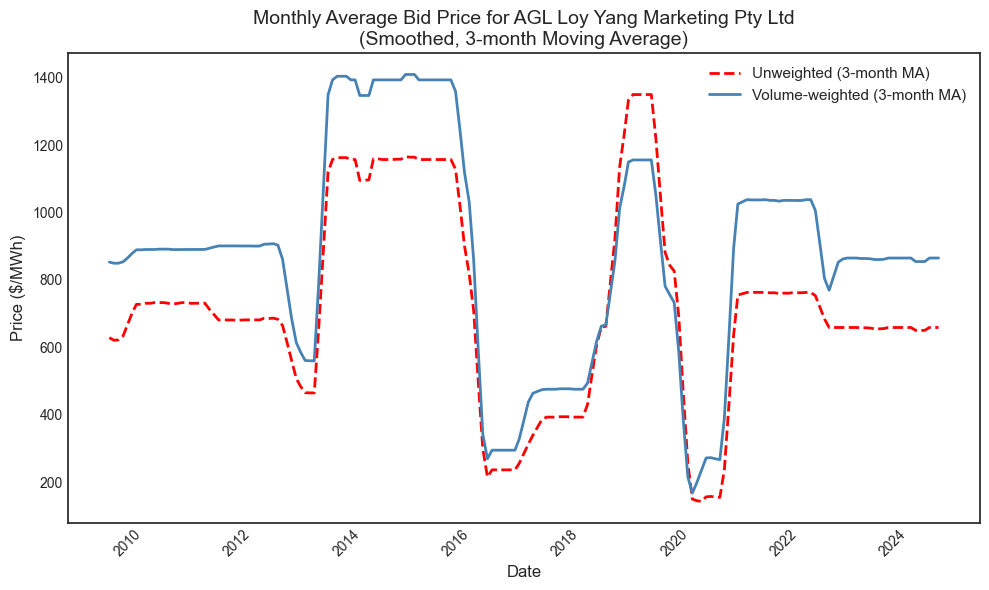

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:33: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


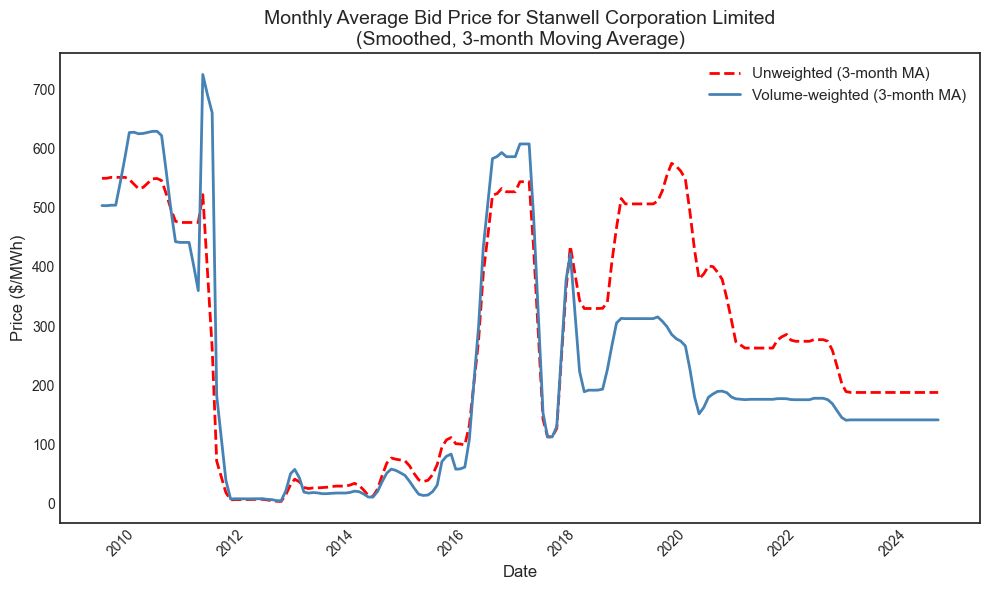

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:33: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


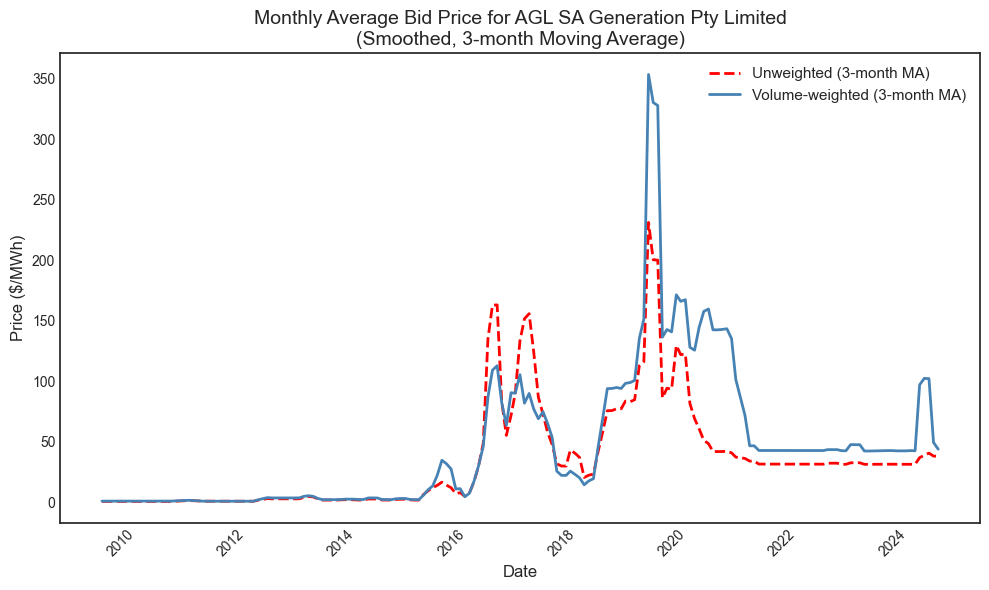

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:33: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


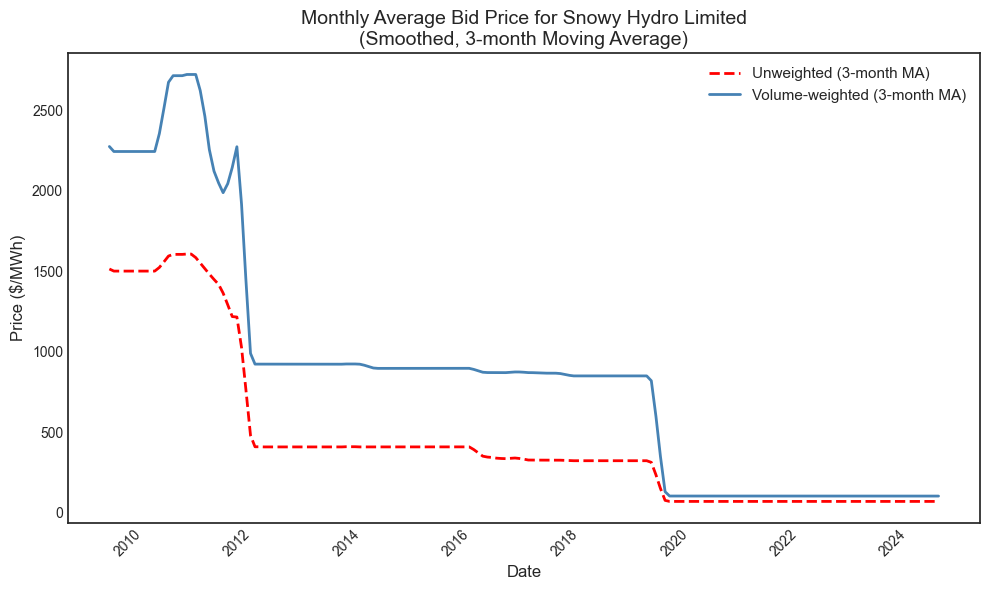

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:33: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/2515192235.py:19: RuntimeWarning: invalid value encountered in scalar divide
  return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()


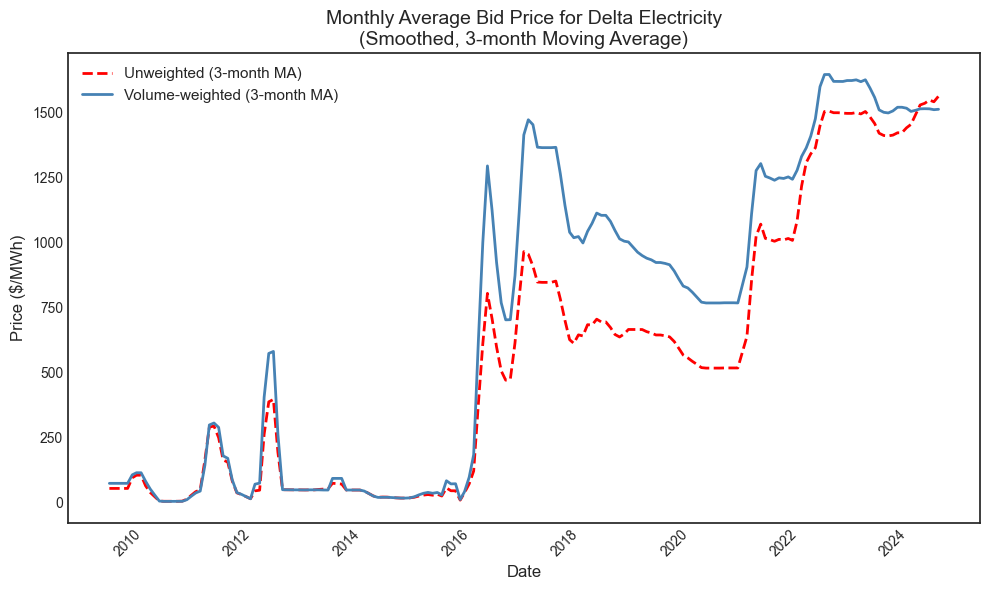

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Example list of top participants you found ---
top_participants = [
    "AGL Macquarie Pty Limited",
    "CS Energy Limited",
    "Origin Energy Electricity Limited",
    "Hydro-Electric Corporation",
    "AGL Loy Yang Marketing Pty Ltd",
    "Stanwell Corporation Limited",
    "AGL SA Generation Pty Limited",
    "Snowy Hydro Limited",
    "Delta Electricity",
    # ... add more if needed
]

def volume_weighted_price(subdf):
    return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()

for participant in top_participants:
    # 1) Filter for a single participant and remove bids above $5,000/MWh
    participant_df = df[df["Participant"] == participant].copy()
    participant_df = participant_df[participant_df["BIDPRICE"] <= 5000]
    
    if participant_df.empty:
        print(f"No valid data for {participant} after filtering; skipping.")
        continue
    
    # 2) Resample monthly: unweighted and volume-weighted
    monthly_unweighted = (
        participant_df["BIDPRICE"]
        .resample("M")
        .mean()
        .rename("UNWEIGHTED_PRICE")
    )
    monthly_weighted = (
        participant_df
        .resample("M")
        .apply(volume_weighted_price)
        .rename("WEIGHTED_PRICE")
    )
    
    # 3) Combine and drop months with missing values
    monthly_df = pd.concat([monthly_unweighted, monthly_weighted], axis=1).dropna()
    if monthly_df.empty:
        print(f"No valid monthly data for {participant} after resampling; skipping.")
        continue
    
    # 4) Smooth with a 3-month moving average (adjust window as needed)
    window_size = 3
    monthly_df["UNWEIGHTED_PRICE_SMOOTH"] = (
        monthly_df["UNWEIGHTED_PRICE"].rolling(window_size, center=True).mean()
    )
    monthly_df["WEIGHTED_PRICE_SMOOTH"] = (
        monthly_df["WEIGHTED_PRICE"].rolling(window_size, center=True).mean()
    )
    
    # 5) Plot each participant on its own figure with an updated title indicating monthly averages
    plt.style.use("seaborn-v0_8-white")
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(
        monthly_df.index,
        monthly_df["UNWEIGHTED_PRICE_SMOOTH"],
        color="red",
        linestyle="--",
        linewidth=2,
        label="Unweighted (3-month MA)"
    )
    ax.plot(
        monthly_df.index,
        monthly_df["WEIGHTED_PRICE_SMOOTH"],
        color="steelblue",
        linestyle="-",
        linewidth=2,
        label="Volume-weighted (3-month MA)"
    )
    
    ax.set_title(
        f"Monthly Average Bid Price for {participant}\n(Smoothed, 3-month Moving Average)",
        fontsize=14
    )
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Price ($/MWh)", fontsize=12)
    ax.legend(fontsize=11)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/188338942.py:41: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/188338942.py:41: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/188338942.py:41: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/188338942.py:41: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/188338942.py:41: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folde

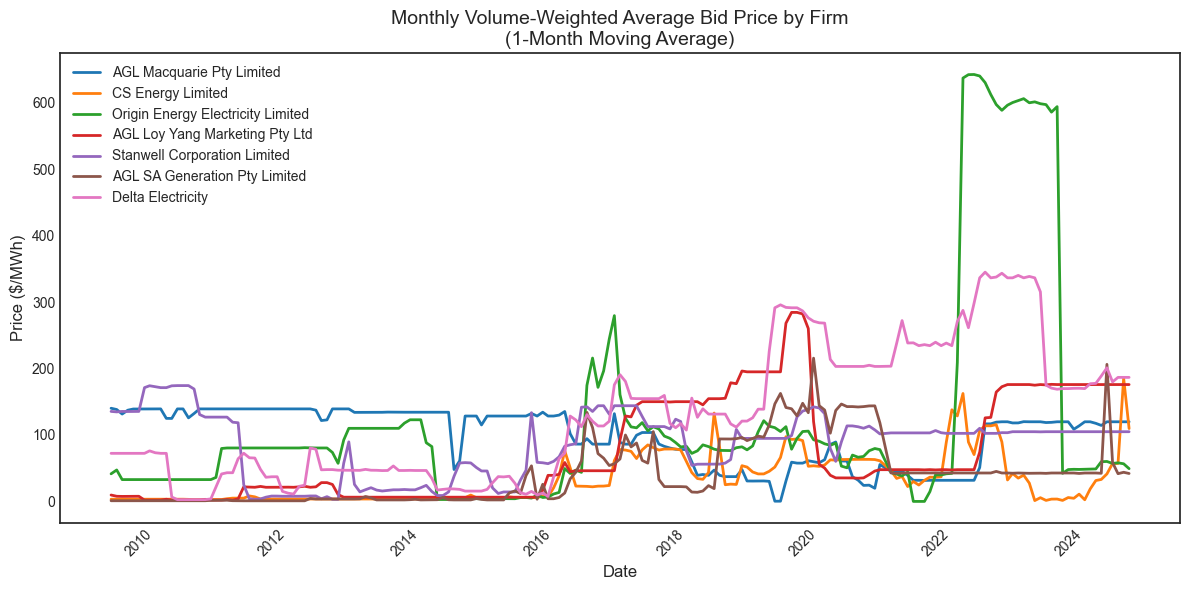

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Example list of top participants you found ---
top_participants = [
    "AGL Macquarie Pty Limited",
    "CS Energy Limited",
    "Origin Energy Electricity Limited",
    "AGL Loy Yang Marketing Pty Ltd",
    "Stanwell Corporation Limited",
    "AGL SA Generation Pty Limited",
    "Delta Electricity",
    # ... add more if needed
]

def volume_weighted_price(subdf):
    # Avoid division by zero if total volume is zero
    if subdf["BIDVOLUME"].sum() == 0:
        return None
    return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()

# Create one figure for all participants
plt.style.use("seaborn-v0_8-white")
fig, ax = plt.subplots(figsize=(12, 6))

# Use matplotlib's default color cycle
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for idx, participant in enumerate(top_participants):
    # Filter for a single participant and remove bids above $5,000/MWh
    participant_df = df[df["Participant"] == participant].copy()
    participant_df = participant_df[participant_df["BIDPRICE"] <= 1000]
    
    if participant_df.empty:
        print(f"No valid data for {participant} after filtering; skipping.")
        continue
    
    # Resample monthly and compute the volume-weighted average bid price
    monthly_weighted = (
        participant_df
        .resample("M")
        .apply(volume_weighted_price)
        .rename("WEIGHTED_PRICE")
    )
    monthly_weighted = monthly_weighted.dropna()
    if monthly_weighted.empty:
        print(f"No valid monthly data for {participant} after resampling; skipping.")
        continue
    
    # Apply a one-month moving average (window=1, which returns the same monthly values)
    monthly_weighted_smoothed = monthly_weighted.rolling(window=1, center=True).mean()
    
    color = colors[idx % len(colors)]
    
    ax.plot(
        monthly_weighted_smoothed.index,
        monthly_weighted_smoothed,
        linestyle="-",
        linewidth=2,
        color=color,
        label=participant
    )

# Set the title and labels for the combined plot
ax.set_title("Monthly Volume-Weighted Average Bid Price by Firm\n(1-Month Moving Average)", fontsize=14)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Price ($/MWh)", fontsize=12)
ax.legend(fontsize=10, loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/188338942.py:41: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/188338942.py:41: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/188338942.py:41: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/188338942.py:41: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folders/xw/3fpv2dn948lcf41k_wd6vbxh0000gn/T/ipykernel_82893/188338942.py:41: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/var/folde

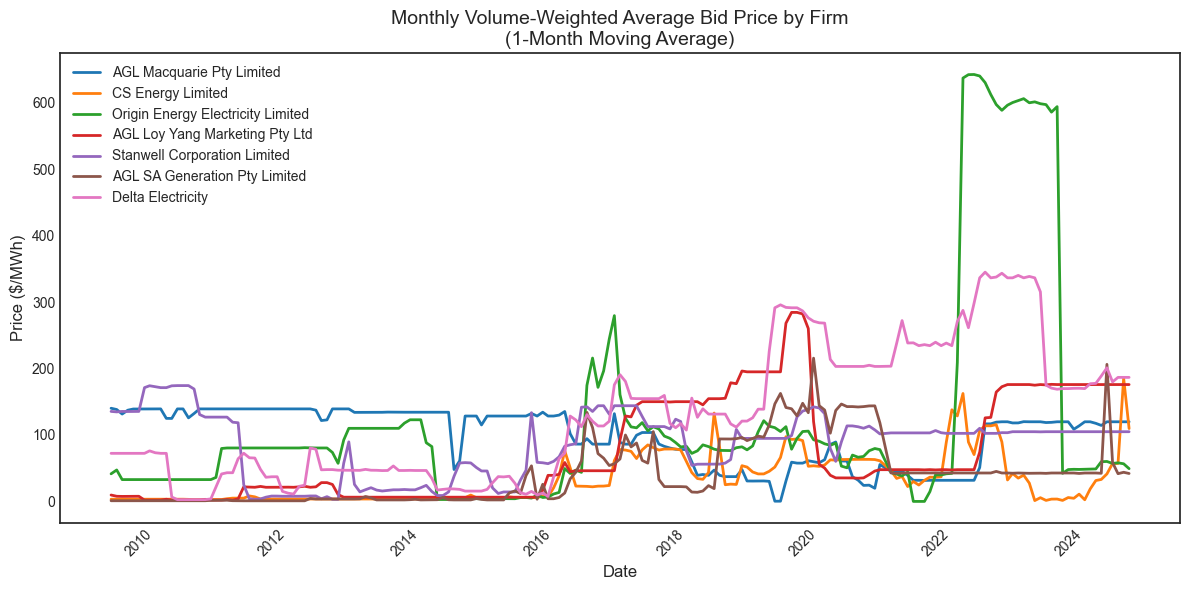

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Example list of top participants you found ---
top_participants = [
    "AGL Macquarie Pty Limited",
    "CS Energy Limited",
    "Origin Energy Electricity Limited",
    "AGL Loy Yang Marketing Pty Ltd",
    "Stanwell Corporation Limited",
    "AGL SA Generation Pty Limited",
    "Delta Electricity",
    # ... add more if needed
]

def volume_weighted_price(subdf):
    # Avoid division by zero if total volume is zero
    if subdf["BIDVOLUME"].sum() == 0:
        return None
    return (subdf["BIDPRICE"] * subdf["BIDVOLUME"]).sum() / subdf["BIDVOLUME"].sum()

# Create one figure for all participants
plt.style.use("seaborn-v0_8-white")
fig, ax = plt.subplots(figsize=(12, 6))

# Use matplotlib's default color cycle
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for idx, participant in enumerate(top_participants):
    # Filter for a single participant and remove bids above $5,000/MWh
    participant_df = df[df["Participant"] == participant].copy()
    participant_df = participant_df[participant_df["BIDPRICE"] <= 1000]
    
    if participant_df.empty:
        print(f"No valid data for {participant} after filtering; skipping.")
        continue
    
    # Resample monthly and compute the volume-weighted average bid price
    monthly_weighted = (
        participant_df
        .resample("M")
        .apply(volume_weighted_price)
        .rename("WEIGHTED_PRICE")
    )
    monthly_weighted = monthly_weighted.dropna()
    if monthly_weighted.empty:
        print(f"No valid monthly data for {participant} after resampling; skipping.")
        continue
    
    # Apply a one-month moving average (window=1, which returns the same monthly values)
    monthly_weighted_smoothed = monthly_weighted.rolling(window=1, center=True).mean()
    
    color = colors[idx % len(colors)]
    
    ax.plot(
        monthly_weighted_smoothed.index,
        monthly_weighted_smoothed,
        linestyle="-",
        linewidth=2,
        color=color,
        label=participant
    )

# Set the title and labels for the combined plot
ax.set_title("Monthly Volume-Weighted Average Bid Price by Firm\n(1-Month Moving Average)", fontsize=14)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Price ($/MWh)", fontsize=12)
ax.legend(fontsize=10, loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()